Imports

In [1]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

In [2]:
df = pd.read_excel("Kittchen PNL Data.xlsx", header=1)

df.head()

,MONTH,CITY,STORE,STATUS,ZONE MAPPING,ORDER COUNT,CART SALES,DISCOUNT,NET REVENUE,IDEAL FOOD COST,GROSS MARGIN,KITCHEN EBITDA,VARIANCE,REVENUE COHORT,CM COHORT,EBITDA CATEGORY,EBITDA COHORT
0,Oct-2023,Ahmedabad,Ramos-Martin,Inactive,West,14270,6554333.68,1163493.98,5434068.17,1763679.62,3614747.39,2374914.55,29664.62,INR 20 to 30 lacs,0% to 10%,EBITDA +ve,More than 20%
1,Nov-2023,Ahmedabad,Ramos-Martin,Inactive,West,8528,2637625.82,636015.27,2146679.55,638415.30,1414249.00,151761.82,11769.85,INR 20 to 30 lacs,More than 30%,EBITDA +ve,More than 20%
2,Dec-2023,Ahmedabad,Ramos-Martin,Inactive,West,10798,4364193.67,1283840.18,3188606.71,1085080.58,2036999.44,736811.76,23376.83,INR 30 to 40 lacs,0% to 10%,EBITDA +ve,0% to 10%
3,Jan-2024,Ahmedabad,Ramos-Martin,Inactive,West,7804,3479969.32,854797.46,2734306.33,1180892.50,1451140.55,229924.26,26162.41,INR 20 to 30 lacs,0% to 10%,EBITDA +ve,More than 20%
4,Feb-2024,Ahmedabad,Ramos-Martin,Inactive,West,10060,4771378.71,1290900.38,3602124.88,1114846.94,2394567.16,1114151.65,19944.97,INR 20 to 30 lacs,More than 30%,EBITDA -ve,0% to 10%


In [3]:
df.shape

(2100, 17)

In [4]:
df.columns.tolist()

['MONTH',
 'CITY',
 'STORE',
 'STATUS',
 'ZONE MAPPING',
 'ORDER COUNT',
 'CART SALES',
 'DISCOUNT',
 'NET REVENUE',
 'IDEAL FOOD COST',
 'GROSS MARGIN',
 'KITCHEN EBITDA',
 'VARIANCE',
 'REVENUE COHORT',
 'CM COHORT',
 'EBITDA CATEGORY',
 'EBITDA COHORT']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2100 entries, 0 to 2099
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MONTH            2100 non-null   object 
 1   CITY             2100 non-null   object 
 2   STORE            2100 non-null   object 
 3   STATUS           2100 non-null   object 
 4   ZONE MAPPING     2100 non-null   object 
 5   ORDER COUNT      2100 non-null   int64  
 6   CART SALES       2100 non-null   float64
 7   DISCOUNT         2100 non-null   float64
 8   NET REVENUE      2100 non-null   float64
 9   IDEAL FOOD COST  2100 non-null   float64
 10  GROSS MARGIN     2100 non-null   float64
 11  KITCHEN EBITDA   2100 non-null   float64
 12  VARIANCE         2100 non-null   float64
 13  REVENUE COHORT   2100 non-null   object 
 14  CM COHORT        2100 non-null   object 
 15  EBITDA CATEGORY  2100 non-null   object 
 16  EBITDA COHORT    2100 non-null   object 
dtypes: float64(7),

In [6]:
df.isnull().sum()

,0
MONTH,0
CITY,0
STORE,0
STATUS,0
ZONE MAPPING,0
ORDER COUNT,0
CART SALES,0
DISCOUNT,0
NET REVENUE,0
IDEAL FOOD COST,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [10]:
numeric_cols = [
    "NET REVENUE",
    "GROSS MARGIN",
    "KITCHEN EBITDA",
    "VARIANCE"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

Gross Margin

In [11]:
df["GM%"] = (
    df["GROSS MARGIN"] /
    df["NET REVENUE"]
) * 100

EBITDA %

In [12]:
df["EBITDA%"] = (
    df["KITCHEN EBITDA"] /
    df["NET REVENUE"]
) * 100

Variance %

In [13]:
df["VARIANCE%"] = (
    df["VARIANCE"] /
    df["NET REVENUE"]
) * 100

**Revenue Analysis**

In [14]:
monthly_rev = df.groupby("MONTH")["NET REVENUE"].sum().reset_index()

monthly_rev

,MONTH,NET REVENUE
0,Dec-2023,1.211609e+09
1,Feb-2024,1.213152e+09
2,Jan-2024,1.247391e+09
3,Mar-2024,1.232936e+09
4,Nov-2023,1.215371e+09
5,Oct-2023,1.240710e+09


In [15]:
fig = px.line(
    monthly_rev,
    x="MONTH",
    y="NET REVENUE",
    markers=True,
    title="Monthly Revenue Trend"
)

fig.show()

 The line chart reveals fluctuations in net revenue across the observed months. While the overall trend suggests sustained activity, there are visible peaks and troughs. For instance, January 2024 recorded the highest net revenue (1.247 billion), potentially indicating seasonal demand or successful campaigns, whereas December 2023 saw the lowest (1.211 billion). Understanding the drivers behind these monthly variations is key for forecasting and strategic planning.

**Gross Margin Analysis**

In [16]:
city_gm = df.groupby("CITY")["GROSS MARGIN"].sum().reset_index()

city_gm

,CITY,GROSS MARGIN
0,Ahmedabad,1.081796e+09
1,Bangalore,8.291170e+08
2,Hyderabad,8.854015e+08
3,Mumbai,7.533738e+08
4,Pune,7.414101e+08


In [17]:
fig = px.bar(
    city_gm,
    x="CITY",
    y="GROSS MARGIN",
    color="CITY",
    title="City-wise Gross Margin"
)

fig.show()

We observed significant differences in gross margins across cities. Ahmedabad leads with the highest gross margin (~1.08 billion), followed by Hyderabad and Bangalore. Pune and Mumbai show comparatively lower gross margins. This suggests varying operational efficiencies or market conditions across locations. Further investigation into cost structures, pricing strategies, and local competition in lower-margin cities could unlock optimization opportunities.

**EBITDA Analysis**

In [18]:
store_ebitda = (
    df.groupby("STORE")["KITCHEN EBITDA"]
    .sum()
    .sort_values(ascending=False)
)

store_ebitda.head(10)

,KITCHEN EBITDA
STORE,
Smith Ltd,12096497.47
Adams LLC,11720624.21
Sanders Ltd,11702593.79
Jimenez LLC,9170224.04
Sanchez and Sons,9167939.50
Fuller LLC,7620794.46
"Mahoney, Dixon and Hobbs",7537180.56
Rose and Sons,7499551.77
Barnes PLC,7254693.48


In [19]:
top_10 = store_ebitda.head(10)

In [20]:
bottom_10 = store_ebitda.tail(10)

In [21]:
fig = px.bar(
    x=top_10.values,
    y=top_10.index,
    orientation='h',
    title="Top EBITDA Stores"
)

fig.show()

Top Performers: Stores like 'Smith Ltd', 'Adams LLC', and 'Sanders Ltd' are consistently among the top 10 contributors to Kitchen EBITDA, demonstrating strong profitability and operational excellence. These stores could serve as benchmarks for best practices.                                        
Underperformers: On the other end, 'Andrews, Reed and Silva' stands out with a negative KITCHEN EBITDA (~-779,236.85), indicating significant losses. This store, along with others in the bottom 10, requires immediate attention, potentially through operational audits, cost reduction initiatives, or strategic interventions.

**Variance Analysis**

In [22]:
high_variance = df[df["VARIANCE"] > 25000]

high_variance[
    ["STORE", "CITY", "VARIANCE"]
].head()

,STORE,CITY,VARIANCE
0,Ramos-Martin,Ahmedabad,29664.62
3,Ramos-Martin,Ahmedabad,26162.41
6,Burke-Johnson,Pune,25597.51
8,Burke-Johnson,Pune,28723.10
10,Burke-Johnson,Pune,29252.97


**Correlation Analysis**

In [23]:
corr = df[
    [
        "NET REVENUE",
        "GROSS MARGIN",
        "KITCHEN EBITDA",
        "VARIANCE"
    ]
].corr()

corr

,NET REVENUE,GROSS MARGIN,KITCHEN EBITDA,VARIANCE
NET REVENUE,1.000000,0.932511,0.921845,-0.022012
GROSS MARGIN,0.932511,1.000000,0.987902,-0.034416
KITCHEN EBITDA,0.921845,0.987902,1.000000,-0.034194
VARIANCE,-0.022012,-0.034416,-0.034194,1.000000


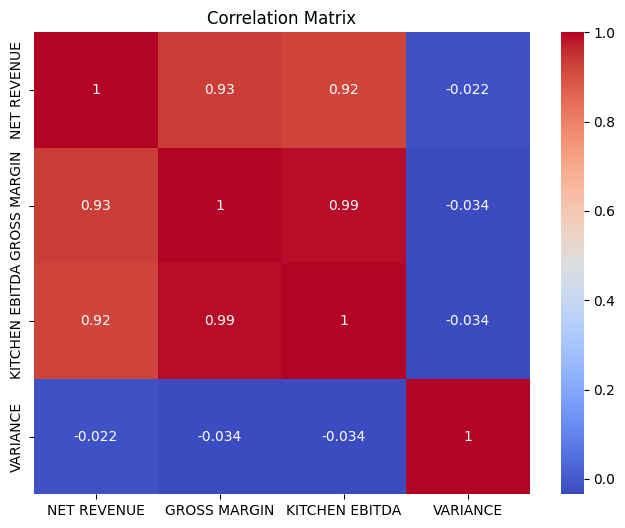

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

Correlation Analysis: The heatmap clearly demonstrates a strong positive correlation between 'NET REVENUE', 'GROSS MARGIN', and 'KITCHEN EBITDA' (all correlation coefficients are above 0.9). This is expected, as higher revenue naturally leads to higher gross margin and EBITDA, assuming costs are controlled. Conversely, 'VARIANCE' shows a very weak negative correlation with these metrics (close to 0), indicating that it largely operates independently and is not directly driven by the same factors influencing revenue and profitability. This independence suggests that 'VARIANCE' needs to be managed and understood separately from the core revenue-generating processes.

**Store Segmentation**

In [25]:
def revenue_bucket(x):

    if x < 1500000:
        return "Low Revenue"

    elif x < 3500000:
        return "Medium Revenue"

    else:
        return "High Revenue"

df["Revenue_Category"] = df["NET REVENUE"].apply(revenue_bucket)

In [26]:
df["Revenue_Category"].value_counts()

,count
Revenue_Category,
Medium Revenue,1112
High Revenue,988


**Profitability Analysis**

In [27]:
df["Profitability"] = np.where(
    df["KITCHEN EBITDA"] >= 0,
    "Profitable",
    "Loss Making"
)

In [28]:
fig = px.pie(
    df,
    names="Profitability",
    title="Profitability Distribution"
)

fig.show()

Overall Profitability Distribution: Our analysis shows that a significant portion of the data entries represents profitable operations (where KITCHEN EBITDA is >= 0), which is a positive indicator for the business's health. However, the presence of 'Loss Making' entries, as highlighted by the pie chart, necessitates a focus on improving the profitability of those specific segments or stores.                                     
High Variance Instances: We identified 546 instances where 'VARIANCE' exceeded 25,000. These high variance values, seen in stores like 'Ramos-Martin' in Ahmedabad and 'Burke-Johnson' in Pune, signify unpredictable deviations from expected financial outcomes. This could be due to unexpected costs, supply chain disruptions, or erratic sales. Investigating the root causes of these variances is crucial for better financial control and risk management.